In [1]:
# %pip install -q "matplotlib>=3.7,<3.9" celluloid modula


from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch import optim

from celluloid import Camera


some plotting fuctions

In [10]:
def plot_mapping(X, Y):
    # Convert to numpy for plotting
    X_np = X.detach().numpy()
    Y_np = Y.detach().numpy()


    #Plot settings
    # ----------------------------
    z_in = 0.0
    z_out = 5.0

    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_proj_type('ortho')
    ax.view_init(elev=25, azim=135)

    # Draw the two planes
    # ----------------------------
    # ----------------------------
    # Draw the two gray planes with black square borders
    # ----------------------------
    grid = np.linspace(-1, 1, 20)
    U, V = np.meshgrid(grid, grid)

    Z_in = np.zeros_like(U) + z_in
    Z_out = np.zeros_like(U) + z_out

    # gray planes
    ax.plot_surface(
        U, V, Z_in,
        color="lightgray",
        alpha=0.35,
        linewidth=0,
        shade=False
    )

    ax.plot_surface(
        U, V, Z_out,
        color="lightgray",
        alpha=0.35,
        linewidth=0,
        shade=False
    )

    # black square border for input plane
    ax.plot([-1,  1], [-1, -1], [z_in, z_in], color="black", linewidth=1)
    ax.plot([-1,  1], [ 1,  1], [z_in, z_in], color="black", linewidth=1)
    ax.plot([-1, -1], [-1,  1], [z_in, z_in], color="black", linewidth=1)
    ax.plot([ 1,  1], [-1,  1], [z_in, z_in], color="black", linewidth=1)

    # black square border for output plane
    ax.plot([-1,  1], [-1, -1], [z_out, z_out], color="black", linewidth=1)
    ax.plot([-1,  1], [ 1,  1], [z_out, z_out], color="black", linewidth=1)
    ax.plot([-1, -1], [-1,  1], [z_out, z_out], color="black", linewidth=1)
    ax.plot([ 1,  1], [-1,  1], [z_out, z_out], color="black", linewidth=1)


    # Plot input and output points
    # ----------------------------
    ax.scatter(
        X_np[:, 0], X_np[:, 1], np.full(N, z_in),
        s=12, alpha=0.7, depthshade=False,c='gray'
    )

    ax.scatter(
        Y_np[:, 0], Y_np[:, 1], np.full(N, z_out),
        s=12, alpha=0.7, depthshade=False,c='gray'
    )


    #  Draw mapping lines
    # ----------------------------
    n_lines = N
    idx = np.random.choice(N, size=n_lines, replace=False)

    for i in idx:
        ax.plot(
            [X_np[i, 0], Y_np[i, 0]],
            [X_np[i, 1], Y_np[i, 1]],
            [z_in, z_out],
            '--',
            alpha=0.65,
            linewidth=1.,
            c='red'
        )




    # Axis formatting
    ax.set_xlim(-1, 1)
    ax.set_xticks([-1,0,1])
    ax.set_yticks([-1,0,1])
    ax.set_ylim(-1, 1)
    ax.set_zlim(-0, z_out + 0.5)

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("plane")

    # Make the box proportions reasonable
    ax.set_box_aspect((1, 1, 0.8))

    
    #ax.legend()

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    plt.tight_layout()
    ax.grid(False)
    ax.set_zticks([])
    ax.set_zlabel("")
    # hide the z-axis line itself
    ax.yaxis.line.set_alpha(0)
    ax.xaxis.line.set_alpha(0)
    ax.zaxis.line.set_alpha(0)

    # make wure rthe x and y axes are inverted so that the points are in the correct quadrants
    #ax.invert_xaxis()
    ax.invert_yaxis()
    plt.show()

In [11]:
n_per_axis = 10

x1 = torch.linspace(-1, 1, n_per_axis)
x2 = torch.linspace(-1, 1, n_per_axis)
N = n_per_axis * n_per_axis 
X1, X2 = torch.meshgrid(x1, x2, indexing="ij")

# flatten grid into [N, 2]
X = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=1)


# 2D linear 

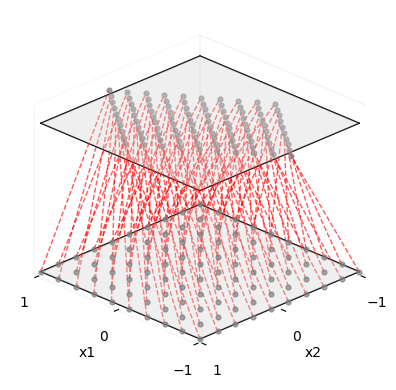

In [14]:
Linear= nn.Linear(2, 2, bias=False) # just a linear transformation (matrix multiplication) without bias
Y  = Linear(X)
plot_mapping(X, Y)

In [10]:
# yoy can also inspect the weight matrix of the linear transformation to see how it transforms the input space
Linear.weight

Parameter containing:
tensor([[-0.3516, -0.3551],
        [-0.6744, -0.3977]], requires_grad=True)

# 2D-Relu

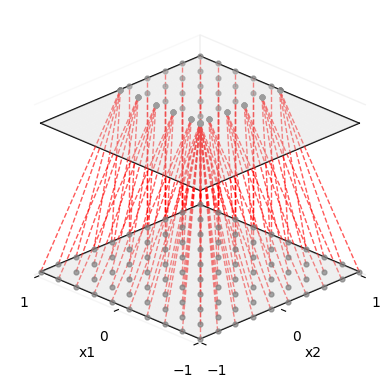

In [12]:
relu = nn.ReLU()
Y = relu(X)

plot_mapping(X, Y)

# L1 norm

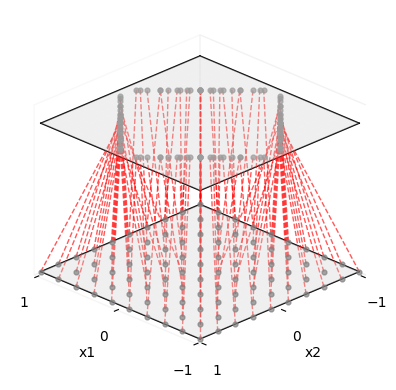

In [16]:
Y = F.normalize(X, p=1, dim=1)  # normalize each row (point) to have unit L2 norm
plot_mapping(X, Y)


# L2 norm

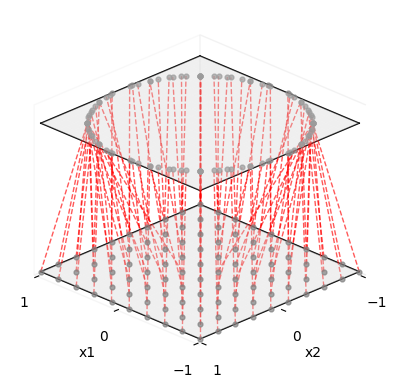

In [20]:
Y = F.normalize(X, p=2, dim=1)  # normalize each row (point) to have unit L2 norm
plot_mapping(X, Y)


# softmax

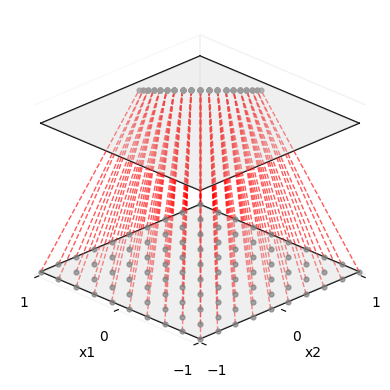

In [13]:
soft_max = nn.Softmax()
Y = soft_max(X)

plot_mapping(X, Y)